In [1]:
"""
This file contain functions used in NPSC method. 
Mar 3rd 2024: 
All piecewiseGQ2D functions are replaced by PiecewiseGQ2D_weights_points function. 
Use global integration points and weights 
Use a global coefficient function, target function, rhs function 
"""
import torch
import numpy as np
import sympy as sp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math 
import time
import sys
import scipy 
from scipy.sparse import linalg
from pathlib import Path
import itertools
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu"  
from scipy.stats import qmc
from multiprocessing.pool import Pool
from multiprocessing.pool import ThreadPool

pi = torch.tensor(np.pi,dtype=torch.float64)
torch.set_default_dtype(torch.float64)

import sys, os
sys.path.append(os.path.abspath("../"))
from utils_quad_init import PiecewiseGQ1D_weights_points, PiecewiseGQ2D_weights_points, PiecewiseGQ3D_weights_points, initialize_w_b_uniform, initialize_w_b_sphere, initialize_w_b_petrushev
from utils_quad_init import model_tanh 

def tanh_activation_dx(x): 
    return 1/torch.cosh(x)**2  

## models 

In [2]:
class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1
    def evaluate_derivative(self, x, i):
        if self.k == 1:
            u1 = self.fc2(torch.heaviside(self.fc1(x),ZERO) * self.fc1.weight.t()[i-1:i,:] )
        else:
            u1 = self.fc2(self.k*F.relu(self.fc1(x))**(self.k-1) *self.fc1.weight.t()[i-1:i,:] )  
        return u1

def adjust_neuron_position(my_model, dims = 3):

    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    pts = torch.tensor([0.,1.])
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
    #     print(w,b)
        values = torch.matmul(positions,w.T) # + b
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/50
        if b <= left_end + offset/2 : 
            b = torch.rand(1)*(right_end - left_end - offset) + left_end + offset/2 
            my_model.fc1.bias.data[i] = b 
        if b >= right_end - offset/2 :
            if counter < (dims+1):
#                 print("here")
                counter += 1
            else: # (d + 1) or more 
                b = torch.rand(1)*(right_end - left_end - offset) + left_end + offset/2 
                my_model.fc1.bias.data[i] = b 
    return my_model


## quadrature 

In [ ]:

def minimize_linear_layer_H1_explicit_assemble_efficient(model, target, g_N, weights, integration_points, w_bd, pts_bd, activation = 'tanh',solver="direct" ,memory=2**29):
    """ -div alpha grad u(x) + u = f 
    Parameters
    ----------
    model: 
        nn model
    alpha:
        alpha function
    target:
        rhs function f 
    pts_bd:
        integration points on the boundary, embdedded in the domain 
    """ 
    ZERO = torch.tensor([0.]).to(device)
    start_time = time.time() 
    w = model.fc1.weight.data 
    b = model.fc1.bias.data 
    neuron_num = b.size(0) 
    dim = integration_points.size(1) 
    M = integration_points.size(0)
    # coef_alpha = alpha(integration_points) # alpha  

    total_size = neuron_num * M # memory, number of floating numbers 
    print('total size: {} {} = {}'.format(neuron_num,M,total_size))
    num_batch = total_size//memory + 1 # divide according to memory
    print("num batches: ",num_batch)
    batch_size = M//num_batch
    jac = torch.zeros(b.size(0),b.size(0)).to(device)
    rhs = torch.zeros(b.size(0),1).to(device)
    
    # Assemble the mass matrix term 
    for j in range(0,M,batch_size): 
        end_index = j + batch_size
        if activation == 'tanh': 
            basis_value_col = torch.tanh(integration_points[j:end_index] @ w.t()+ b)
        elif activation == 'relu':
            basis_value_col = F.relu(integration_points[j:end_index] @ w.t()+ b)**(model.k) 
        weighted_basis_value_col = basis_value_col * weights[j:end_index] 
        jac += weighted_basis_value_col.t() @ basis_value_col 
        rhs += weighted_basis_value_col.t() @ (target(integration_points[j:end_index,:])) 

    # Assemble the boundary condition term <g,v>_{\Gamma_N} 

    if g_N != None: # no batch operations for the boundary part, since it is only rhs on the boundary 
        size_pts_bd = int(pts_bd.size(0)/(2*dim))
        bcs_N = g_N(dim)
        for ii, g_ii in bcs_N:
            # pts_bd_ii = pts_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:]
            weighted_g_N = -g_ii(pts_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:])* w_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:]
            basis_value_bd_col = torch.tanh(pts_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:] @ w.t()+ b)
            rhs += basis_value_bd_col.t() @ weighted_g_N

            weighted_g_N = g_ii(pts_bd[(2*ii+1)*size_pts_bd:(2*ii+2)*size_pts_bd,:])* w_bd[(2*ii+1)*size_pts_bd:(2*ii+2)*size_pts_bd,:]
            basis_value_bd_col = torch.tanh(pts_bd[(2*ii+1)*size_pts_bd:(2*ii+2)*size_pts_bd,:] @ w.t()+ b)
            rhs += basis_value_bd_col.t() @ weighted_g_N

    # Stiffness matrix term in the jacobian 
    for dd in range(dim):

        for j in range(0,M,batch_size):  
            end_index = j + batch_size 
            if activation == 'tanh':
                basis_value_dxi_col = tanh_activation_dx(integration_points[j:end_index] @ w.t()+ b) * w.t()[dd:dd+1,:]
                weighted_basis_value_dx_col = basis_value_dxi_col * weights[j:end_index] # * coef_alpha[j:end_index] 
                jac += weighted_basis_value_dx_col.t() @ basis_value_dxi_col 
            elif activation == 'relu':
                if model.k == 1:
                    basis_value_dxi_col = torch.heaviside(integration_points[j:end_index] @ w.t()+ b, ZERO) * w.t()[dd:dd+1,:]
                else:
                    basis_value_dxi_col = model.k * F.relu(integration_points[j:end_index] @ w.t()+ b)**(model.k-1) * w.t()[dd:dd+1,:]
                weighted_basis_value_dxi_col = basis_value_dxi_col * weights[j:end_index] # * coef_alpha[j:end_index] 
                jac += weighted_basis_value_dxi_col.t() @ basis_value_dxi_col

    print("assembling the mass matrix time taken: ", time.time()-start_time) 

    start_time = time.time()    
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    print("solving Ax = b time taken: ", time.time()-start_time)
    return sol, jac, rhs  



In [4]:


def minimize_linear_layer_H1_explicit_assemble_efficient_least_squares(model, target, g_N, weights, integration_points, w_bd, pts_bd, activation = 'tanh',solver="direct" ,memory=2**29):
    """ -div alpha grad u(x) + u = f 
    Parameters
    ----------
    model: 
        nn model
    alpha:
        alpha function
    target:
        rhs function f 
    pts_bd:
        integration points on the boundary, embdedded in the domain 
    """ 
    ZERO = torch.tensor([0.]).to(device)
    start_time = time.time() 
    w = model.fc1.weight.data 
    b = model.fc1.bias.data 
    neuron_num = b.size(0) 
    dim = integration_points.size(1) 
    M = integration_points.size(0)
    # coef_alpha = alpha(integration_points) # alpha  

    total_size = neuron_num * M # memory, number of floating numbers 
    print('total size: {} {} = {}'.format(neuron_num,M,total_size))
    num_batch = total_size//memory + 1 # divide according to memory
    print("num batches: ",num_batch)
    batch_size = M//num_batch
    jac = torch.zeros(M,b.size(0)).to(device)
    rhs = torch.zeros(M,1).to(device)
    
    # Assemble the mass matrix term 
    for j in range(0,M,batch_size): 
        end_index = j + batch_size
        if activation == 'tanh': 
            basis_value_col = torch.tanh(integration_points[j:end_index] @ w.t()+ b)
        elif activation == 'relu':
            basis_value_col = F.relu(integration_points[j:end_index] @ w.t()+ b)**(model.k) 
        weighted_basis_value_col = basis_value_col * (weights[j:end_index]**0.5)
        jac += weighted_basis_value_col 
        rhs +=  (target(integration_points[j:end_index,:])) * (weights[j:end_index]**0.5)

    # Assemble the boundary condition term <g,v>_{\Gamma_N} 

    if g_N != None: # no batch operations for the boundary part, since it is only rhs on the boundary 
        # this part is not implemented. We assume g_N == None. 
        size_pts_bd = int(pts_bd.size(0)/(2*dim))
        bcs_N = g_N(dim)
        for ii, g_ii in bcs_N:
            # pts_bd_ii = pts_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:]
            weighted_g_N = -g_ii(pts_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:])* w_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:]
            basis_value_bd_col = torch.tanh(pts_bd[2*ii*size_pts_bd:(2*ii+1)*size_pts_bd,:] @ w.t()+ b)
            rhs += basis_value_bd_col.t() @ weighted_g_N

            weighted_g_N = g_ii(pts_bd[(2*ii+1)*size_pts_bd:(2*ii+2)*size_pts_bd,:])* w_bd[(2*ii+1)*size_pts_bd:(2*ii+2)*size_pts_bd,:]
            basis_value_bd_col = torch.tanh(pts_bd[(2*ii+1)*size_pts_bd:(2*ii+2)*size_pts_bd,:] @ w.t()+ b)
            rhs += basis_value_bd_col.t() @ weighted_g_N

    # Stiffness matrix term in the jacobian 
    for dd in range(dim):

        for j in range(0,M,batch_size):  
            end_index = j + batch_size 
            if activation == 'tanh':
                basis_value_dxi_col = tanh_activation_dx(integration_points[j:end_index] @ w.t()+ b) * w.t()[dd:dd+1,:]
                weighted_basis_value_dxi_col = basis_value_dxi_col * ( weights[j:end_index]**0.5 )# * coef_alpha[j:end_index] 
                jac += weighted_basis_value_dxi_col 
            elif activation == 'relu':
                if model.k == 1:
                    basis_value_dxi_col = torch.heaviside(integration_points[j:end_index] @ w.t()+ b, ZERO) * w.t()[dd:dd+1,:]
                else:
                    basis_value_dxi_col = model.k * F.relu(integration_points[j:end_index] @ w.t()+ b)**(model.k-1) * w.t()[dd:dd+1,:]
                weighted_basis_value_dxi_col = basis_value_dxi_col * (weights[j:end_index]**0.5) # * coef_alpha[j:end_index] 
                jac += weighted_basis_value_dxi_col.t() 

    print("assembling the mass matrix time taken: ", time.time()-start_time) 

    start_time = time.time()    

    # sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
    sol = scipy.linalg.lstsq(jac.cpu().numpy(),rhs.cpu().numpy())[0]
    sol = torch.from_numpy(sol).to(device).view(1,-1)
    print("solving Ax = b time taken: ", time.time()-start_time)
    return sol # , jac, rhs  



In [110]:
scale =0.8
in_feats = 2 
out_feats = 16 
n1 = int(scale * math.ceil(out_feats**((in_feats - 1)/in_feats))) 
print(n1)

3


In [5]:
def initialize_w_b_petrushev(my_model,R_m,scale = 1):
    w = my_model.fc1.weight
    b = my_model.fc1.bias
    out_feats, in_feats = w.shape
    # print(w.shape)
    device = w.device
    n1 = int(scale * math.ceil(out_feats**((in_feats - 1)/in_feats))) 
    # print(n1)
    n2 = math.ceil(out_feats**(1/in_feats))
    with torch.no_grad():
        if in_feats == 1:  #n by 1 
            weights = torch.ones(n1,1).to(device)
            # weights[:,0] = torch.linspace(-R_m,R_m,n1) 
        elif in_feats == 2:
            weights = torch.zeros(n1,2).to(device)
            theta = np.linspace(0,pi,n1,endpoint=False) 
            theta = torch.tensor(theta).to(device)
            weights[:, 0] = theta.cos()
            weights[:, 1] = theta.sin() 
            #form a tensor product of weights and biases
        elif in_feats == 3: 
            indices = torch.arange(0, n1, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/n1)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            weights = torch.stack((x, y, z), dim=1)
        elif in_feats >= 4: 
            # nn.init.normal_(w, mean = 0, std = 1)
            weights = torch.randn(n1, in_feats).to(device) 
            weights = weights / torch.norm(weights,dim=1).view(-1,1) 

        # form a tensor product of weights and biases 
        weights = torch.tile(weights, (1,n2)).reshape(-1,in_feats) 
        # print("weights shape: ", weights.shape) 
        # print("nn w shape: ", w.shape)
        my_model = model_tanh(in_feats, n1*n2, 1).to(device) 
        biases = torch.linspace(-R_m+0.0001,R_m,n2).to(device)
        # biases = torch.tensor(biases).to(device) 
        biases = torch.tile(biases, (n1,1)).reshape(-1) 
        # w[:,:] = weights[:out_feats,:] 
        my_model.fc1.weight.data[:,:] = weights[:,:]
        my_model.fc1.bias.data[:] = biases[:] 

    return my_model 

def initialize_w_b_sphere(my_model,R_m):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 
    out_feats, in_feats = my_model.fc1.weight.shape 
    if in_feats == 2: 
        indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
        phi = torch.acos(1 - 2*indices/neuron_nums)
        theta = pi * (1 + 5**0.5) * indices
        x = torch.sin(phi) * torch.cos(theta)
        y = torch.sin(phi) * torch.sin(theta)
        z = torch.cos(phi)

        points = torch.stack((x, y, z), dim=1)
        my_model.fc1.weight.data[:,:] = points[:,0:2] * R_m
        my_model.fc1.bias.data[:] = points[:,2] * R_m 
    elif in_feats == 1:
        theta = torch.linspace(0, pi, neuron_nums+1)[:-1]
        w1 = torch.cos(theta) * R_m
        b = torch.sin(theta) * R_m
        my_model.fc1.weight.data[:,0] = w1[:]
        my_model.fc1.bias.data[:] = b[:]
    else: 
        w_b = torch.randn(neuron_nums,in_feats + 1) 
        w_b = w_b / torch.norm(w_b,dim=1).view(-1,1) 
        w_b = w_b * R_m 
        my_model.fc1.weight.data[:,:] = w_b[:,:-1] 
        my_model.fc1.bias.data[:] = w_b[:,-1] 
    return my_model 


Activation: tanh,  Rm: 2
total size: 4 5120 = 20480
num batches:  1
assembling the mass matrix time taken:  0.004659891128540039
solving Ax = b time taken:  0.0024008750915527344
4, condition number: 15704.176382436342
total size: 8 5120 = 40960
num batches:  1
assembling the mass matrix time taken:  0.0013422966003417969
solving Ax = b time taken:  0.00034308433532714844
8, condition number: 178173613637.17538
total size: 16 5120 = 81920
num batches:  1
assembling the mass matrix time taken:  0.0013167858123779297
solving Ax = b time taken:  5.793571472167969e-05
16, condition number: 4.498052005581696e+16
total size: 32 5120 = 163840
num batches:  1
assembling the mass matrix time taken:  0.0018329620361328125
solving Ax = b time taken:  0.0011682510375976562
32, condition number: 6.247113784169294e+16
total size: 64 5120 = 327680
num batches:  1
assembling the mass matrix time taken:  0.005143165588378906
solving Ax = b time taken:  0.0024209022521972656
64, condition number: 2.4900

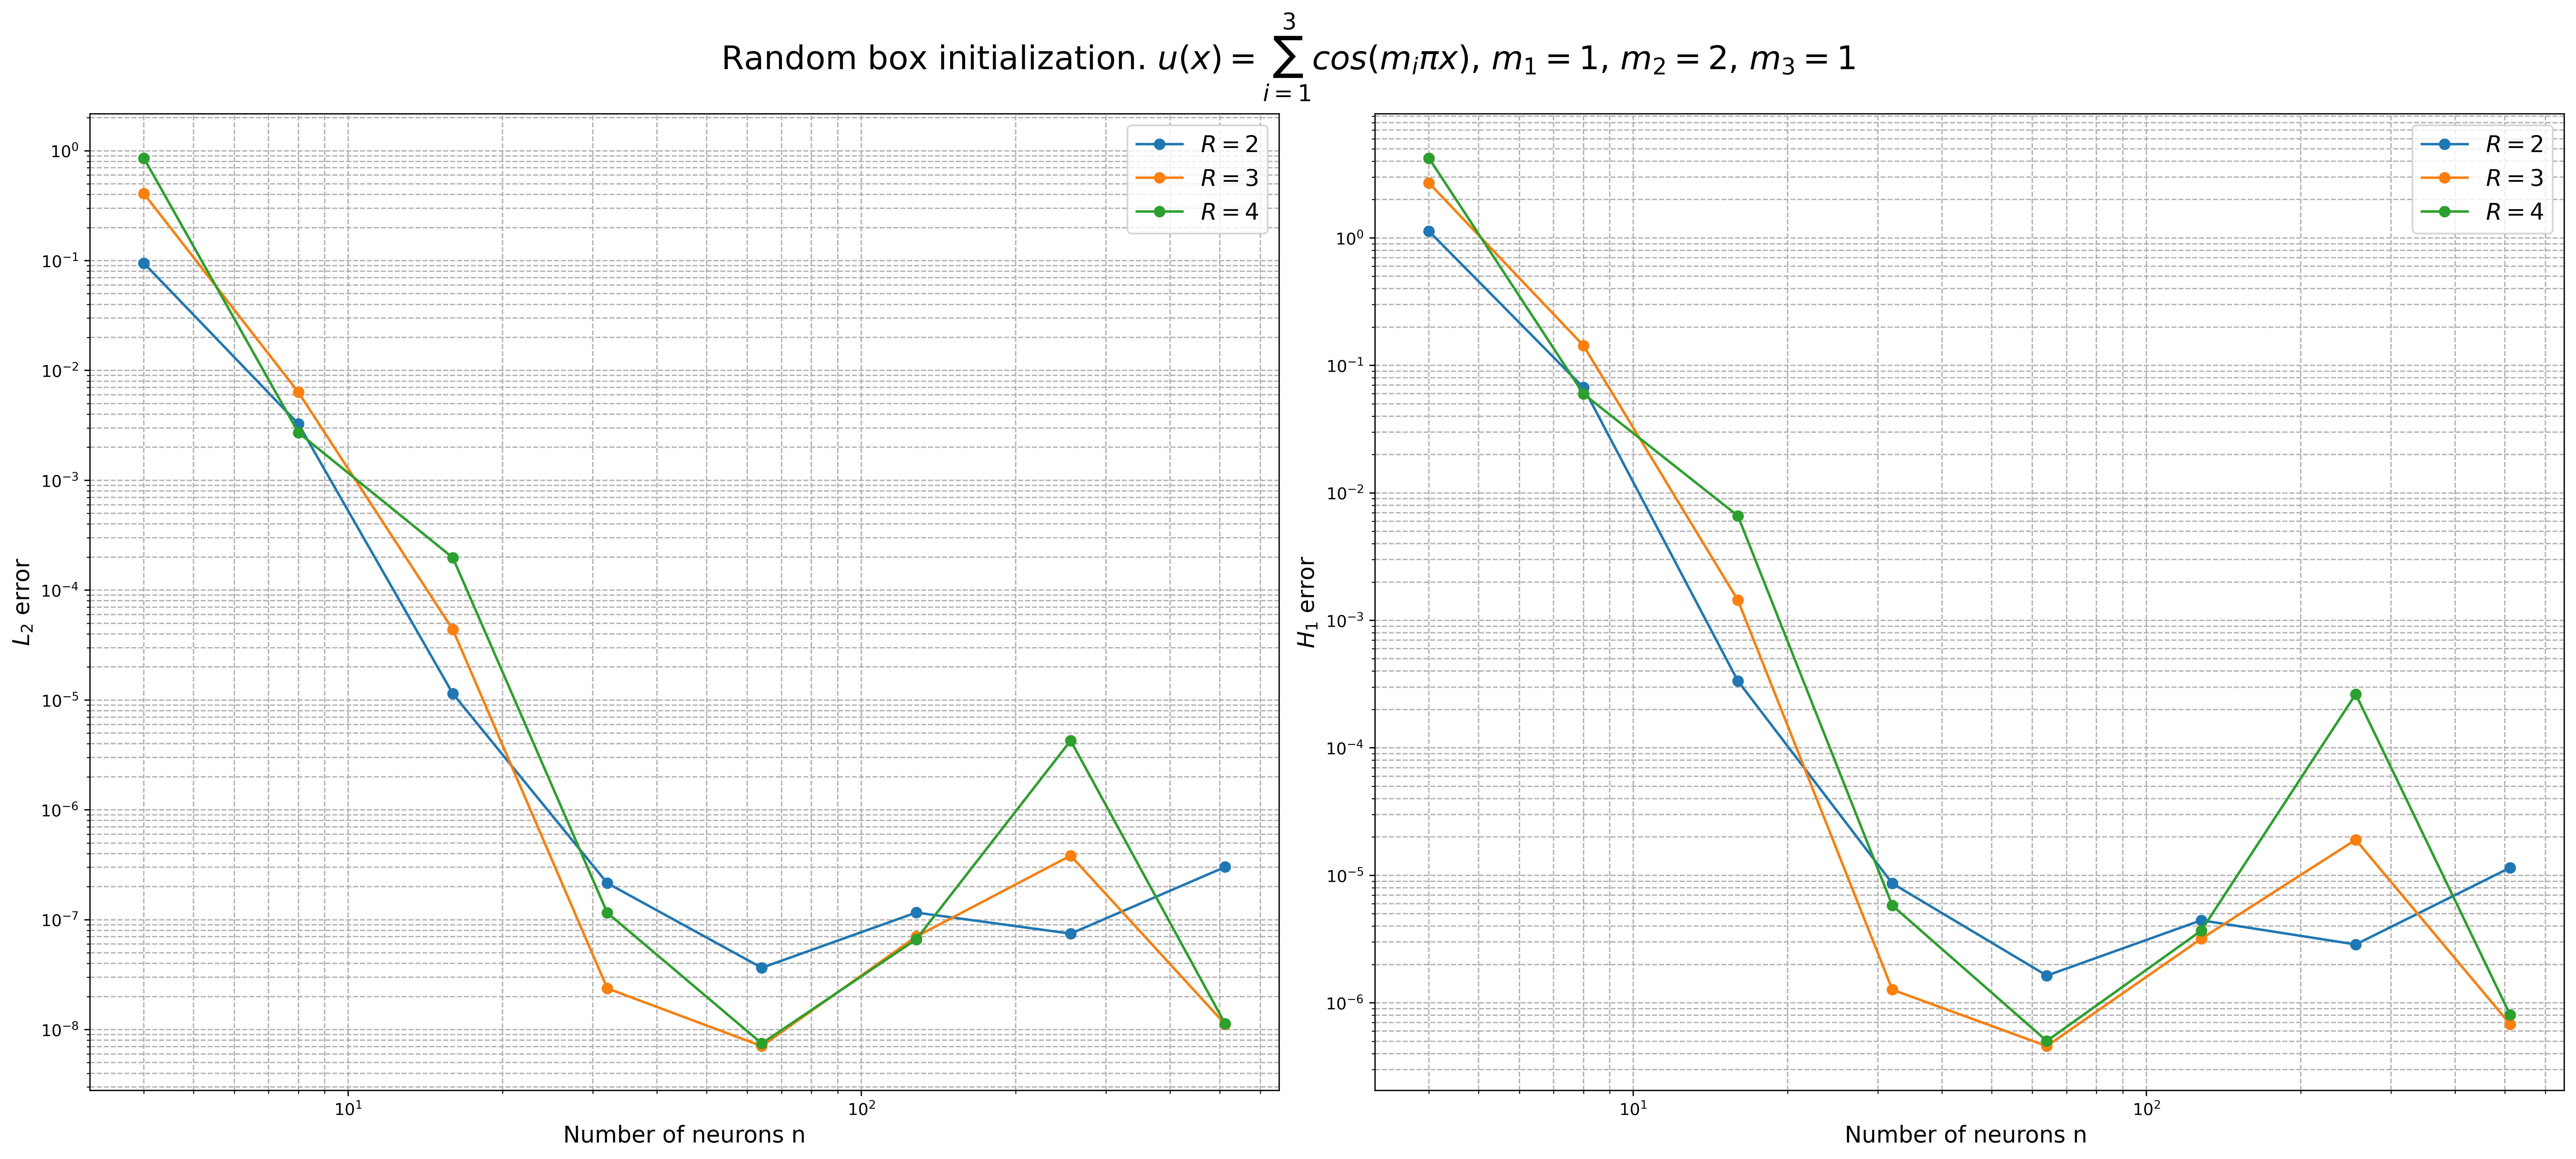

In [6]:
def main(m1,m2,m3):

    def u_exact(x,d=1):
        z1 = torch.prod(torch.cos(m1 * pi * x),dim = 1,keepdim = True)
        z2 = torch.prod(torch.cos(m2 * pi * x),dim = 1,keepdim = True) 
        z3 = torch.prod(torch.cos(m3 * pi * x),dim = 1,keepdim = True) 
        return z1 + z2   + z3 

    def f_rhs(x,d=1):
        z1 = (d * (m1 * pi)**2 + 1)*torch.prod(torch.cos(m1 * pi * x),dim = 1,keepdim = True) 
        z2 = (d * (m2 * pi)**2 + 1)*torch.prod(torch.cos(m2 * pi * x),dim = 1,keepdim = True)
        z3 = (d * (m3 * pi)**2 + 1)*torch.prod(torch.cos(m3 * pi * x),dim = 1,keepdim = True)
        z = z1 + z2 + z3
        return z 

    def u_exact_grad(d=1):
        dim = d # d is global variable defined outside the function 
        grad_list = [] 
        def make_u_i(i):
            def u_i(x): 
                sin_terms = torch.cos(m1 * pi * x)
                cos_term = torch.sin(m1 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = -cos_term  # Replace the first sine term with the cosine term
                z1 = (m1 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)

                sin_terms = torch.cos(m2 * pi * x)
                cos_term = torch.sin(m2 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = -cos_term  # Replace the first sine term
                z2 = (m2 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)

                sin_terms = torch.cos(m3 * pi * x)
                cos_term = torch.sin(m3 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = -cos_term  # Replace the first sine term
                z3 = (m3 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)
                z = z1   + z2 + z3
                return z 
            
            return u_i 
        for i in range(1,dim+1):
            grad_list.append(make_u_i(i))
        return grad_list
    # torch.manual_seed(1)
    # Problem and network parameters:
    d = 1         # spatial dimension (you can change this to, say, 10)
    input_dim = d # spatial
    activation = 'tanh'
    relu_k = 2 
    # neuron_list = [16,32,64,128,256] # 250,500,1000,2000,4000,8000]

    neuron_list = [2**i for i in range(2,10)]
    actual_neuron_list = torch.zeros(len(neuron_list))
    Nx = 1024
    order = 5 
    x_l, x_r = 0, 1
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx,order)
    fig, axes = plt.subplots(1, 2, figsize=(11*2, 10), dpi=400)  
    for Rm in [2,3,4]: # 1e-2,5e-2,1e-1,5e-1,1,2,4 
        print('Activation: {},  Rm: {}'.format(activation,Rm))
        trial_num = 1 
        errors_l2_trials = torch.zeros(trial_num, len(neuron_list)) 
        errors_h1_trials = torch.zeros(trial_num, len(neuron_list)) 
        for i, n in enumerate(neuron_list): # number of hidden units in the ELM

            for trial in range(trial_num):  
                my_model = model_tanh(1, n, 1).to(device) 
                # my_model = initialize_w_b_petrushev(my_model,Rm,scale=1)
                my_model = initialize_w_b_sphere(my_model,Rm) 
                # my_model = initialize_w_b_uniform(my_model, Rm)
                # my_model = model(1, n, 1,k=relu_k).to(device) 
                # my_model = adjust_neuron_position(my_model, dims = d)
                sol,jac,_ = minimize_linear_layer_H1_explicit_assemble_efficient(my_model,f_rhs,None,integration_weights, integration_points, None, None, activation=activation,solver="direct")
                my_model.fc2.weight.data[0,:] = sol[:]
                actual_neuron_list[i] = my_model.fc2.weight.data.size(1)
                print(f"{n}, condition number: {np.linalg.cond(jac.detach().cpu().numpy())}")

                # ------Evaluate the error ------
                with torch.no_grad():
                    u_exact_val = u_exact(integration_points, d) # shape: (M, 1) 
                    diff_sqrd = (u_exact_val - my_model(integration_points))**2 
                    errors_l2_trials[trial,i] = (integration_weights.t() @ diff_sqrd )**0.5
                    u_exact_l2_norm = (integration_weights.t() @  u_exact_val**2 )**0.5

                    u_exact_h1_norm = 0 # compute the error in H1 norm 
                    u_grad = u_exact_grad(d)  
                    for ii, grad_i in enumerate(u_grad):
                        u_pred_grad = my_model.evaluate_derivative(integration_points, ii+1)
                        u_exact_grad_val = grad_i(integration_points)
                        # print(u_pred_grad.size(),u_exact_grad_val.size()) 
                        squared_err = integration_weights.t()@ (u_pred_grad - u_exact_grad_val)**2 
                        errors_h1_trials[trial, i] += squared_err.item() # ith neuron numer 
                        u_exact_h1_norm += integration_weights.t()@ (u_exact_grad_val)**2 
                    errors_h1_trials[trial, i]  = errors_h1_trials[trial, i] **0.5 
                    u_exact_h1_norm = u_exact_h1_norm**0.5 
            
        # mean errors 
        mean_errors_l2 = errors_l2_trials.mean(dim=0)
        mean_errors_h1 = errors_h1_trials.mean(dim=0)  
        print("L2 error {:4e}; H1 error {:4e} ".format(mean_errors_l2[i].item(), mean_errors_h1[i].item()) ) 
        print("L2 norm of u {}; H1 norm of u {} ".format(u_exact_l2_norm.item(), u_exact_h1_norm.item()) )
        print() 
        # Plot the errors
        print(actual_neuron_list, mean_errors_l2)
        axes[0].loglog(actual_neuron_list, mean_errors_l2, 'o-', label=f"$R = {Rm}$") 
        axes[0].set_xlabel('Number of neurons n',fontsize=14)
        axes[0].set_ylabel('$L_2$ error',fontsize=14) 
        axes[0].grid(True, which="both", ls="--") 
        axes[0].legend(fontsize=14)
        # axes[0].set_title('L2 error vs Number of neurons')

        axes[1].loglog(actual_neuron_list, mean_errors_h1, 'o-', label=f"$R = {Rm}$") 
        axes[1].set_xlabel('Number of neurons n ',fontsize=14)
        axes[1].set_ylabel('$H_1$ error',fontsize=14)
        axes[1].grid(True, which="both", ls="--") 
        axes[1].legend(fontsize=14)
        # axes[1].set_title('H1 error vs Number of neurons')

        fig.tight_layout()
        title = f"Random box initialization. $u(x) = \sum_{{i=1}}^{3} cos(m_i \pi x)$, $m_1={m1}$, $m_2={m2}$, $m_3={m3}$"
        fig.suptitle(title,fontsize=20) 

    plt.show() 

if __name__ == '__main__':
    m1,m2,m3 = 1, 2,1
    main(m1,m2,m3)


## 2D


Activation: tanh,  Rm: 1
total size: 4 22500 = 90000
num batches:  1
assembling the mass matrix time taken:  0.004708290100097656
solving Ax = b time taken:  0.0011010169982910156
4, condition number: 260.4248853883282
total size: 8 22500 = 180000
num batches:  1
assembling the mass matrix time taken:  0.005376100540161133
solving Ax = b time taken:  9.298324584960938e-05
8, condition number: 8309.418026919611
total size: 16 22500 = 360000
num batches:  1
assembling the mass matrix time taken:  0.012793779373168945
solving Ax = b time taken:  0.0001087188720703125
16, condition number: 121946365.51999682
total size: 32 22500 = 720000
num batches:  1
assembling the mass matrix time taken:  0.021487951278686523
solving Ax = b time taken:  0.0001220703125
32, condition number: 50053331480024.73
total size: 64 22500 = 1440000
num batches:  1
assembling the mass matrix time taken:  0.03540301322937012
solving Ax = b time taken:  0.00017595291137695312
64, condition number: 8.00695854661215

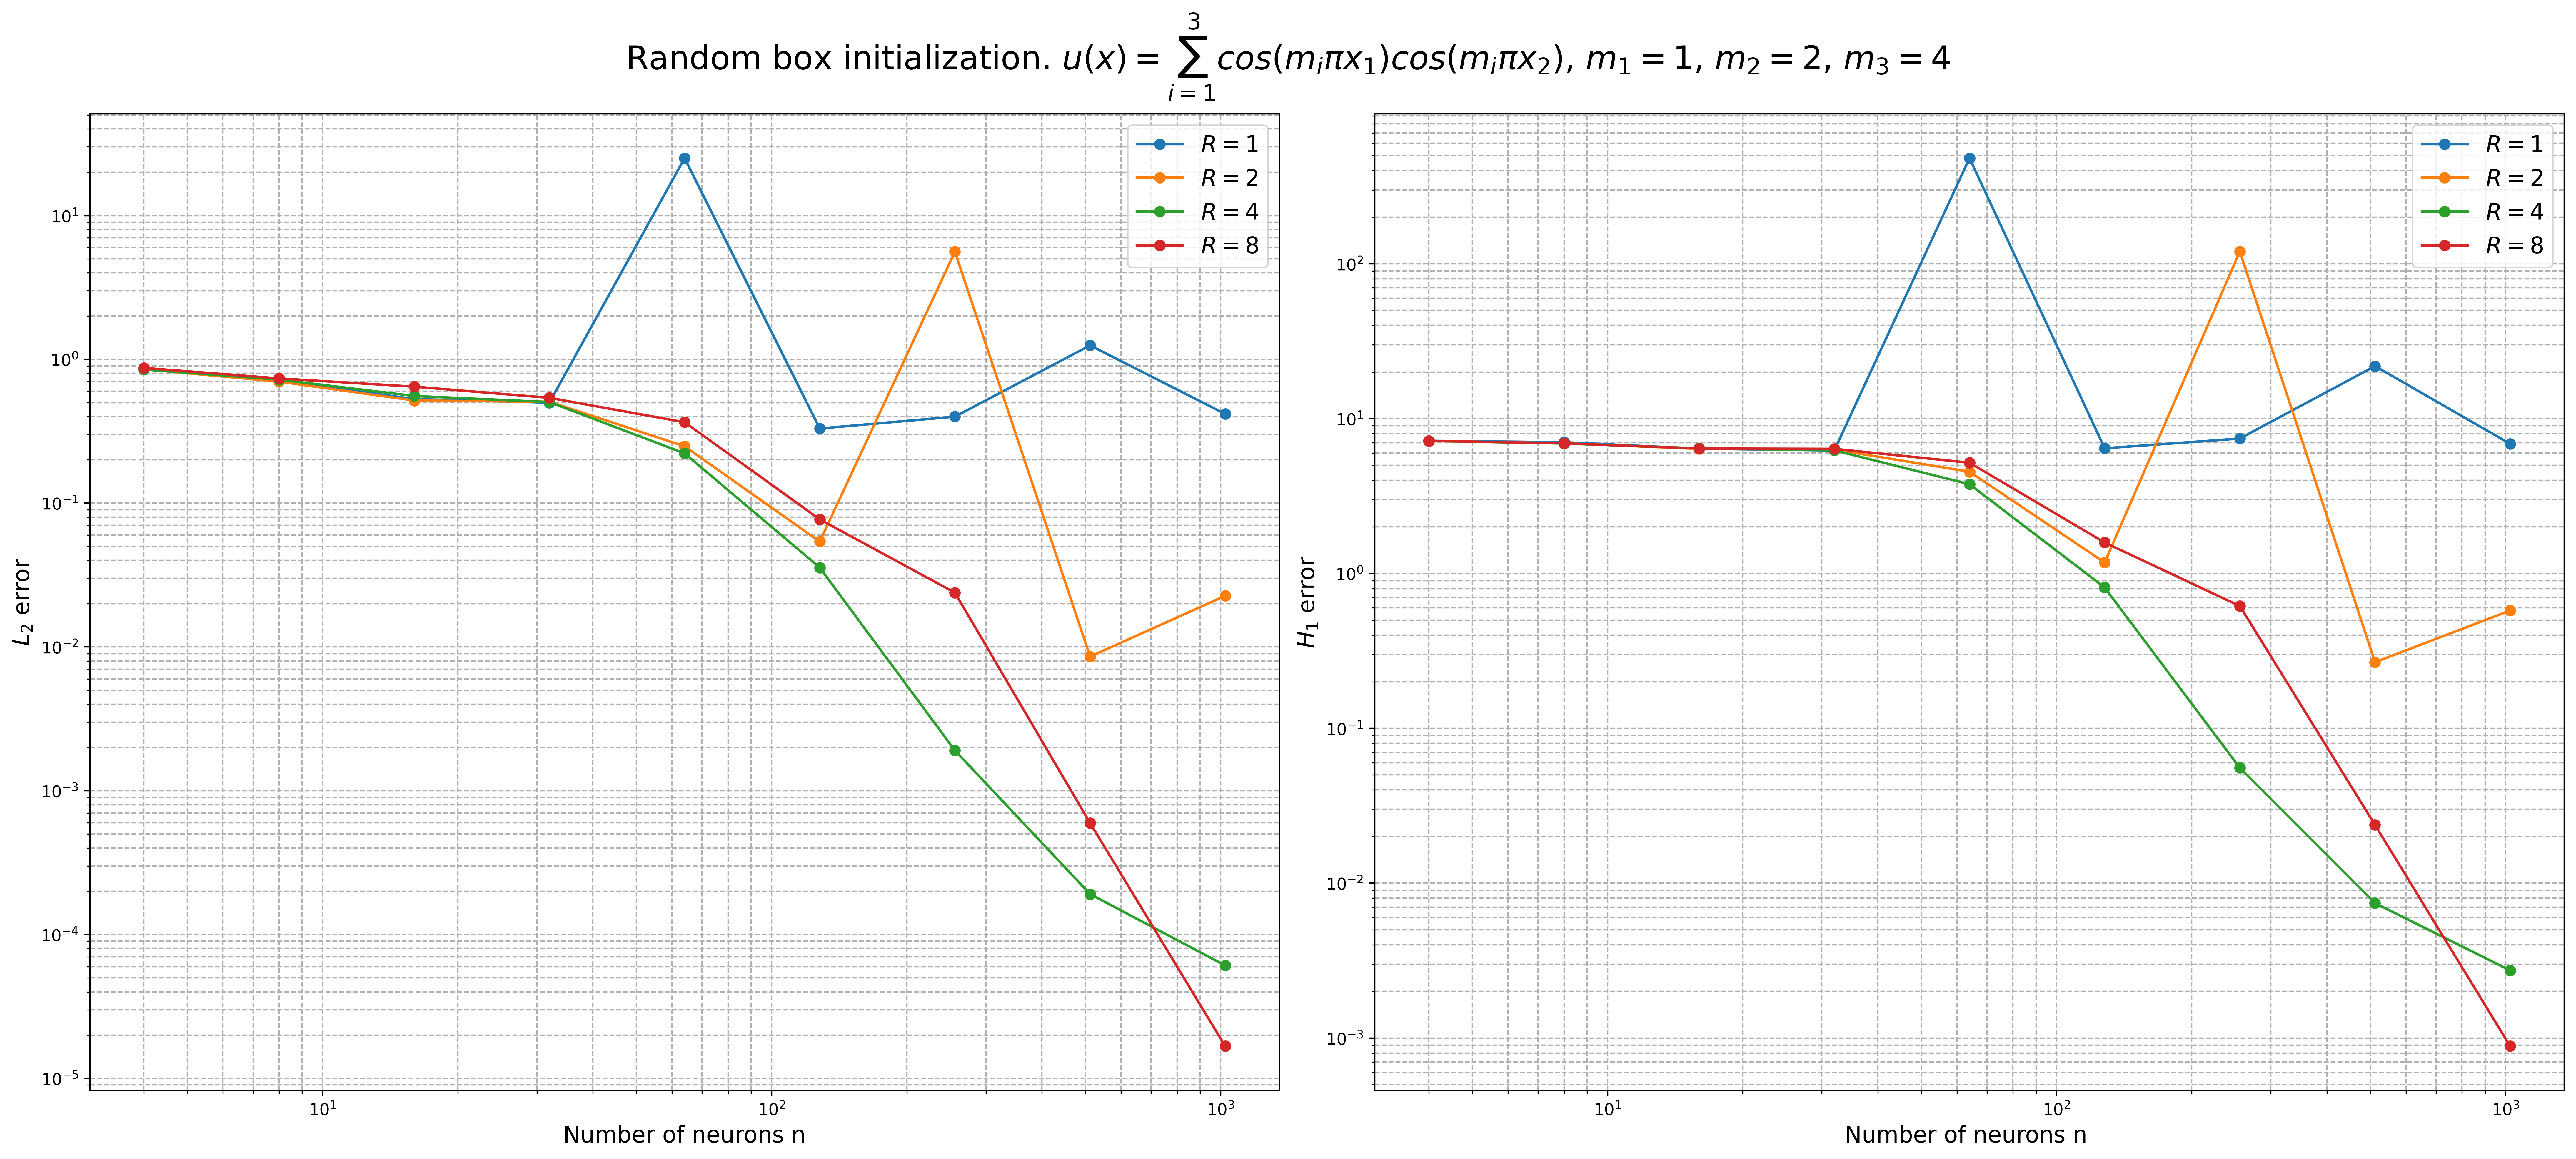

In [7]:
def main(m1,m2,m3):

    def u_exact(x,d=2):
        z1 = torch.prod(torch.cos(m1 * pi * x),dim = 1,keepdim = True)
        z2 = torch.prod(torch.cos(m2 * pi * x),dim = 1,keepdim = True) 
        z3 = torch.prod(torch.cos(m3 * pi * x),dim = 1,keepdim = True) 
        return z1 + z2   + z3 

    def f_rhs(x,d=2):
        z1 = (d * (m1 * pi)**2 + 1)*torch.prod(torch.cos(m1 * pi * x),dim = 1,keepdim = True) 
        z2 = (d * (m2 * pi)**2 + 1)*torch.prod(torch.cos(m2 * pi * x),dim = 1,keepdim = True)
        z3 = (d * (m3 * pi)**2 + 1)*torch.prod(torch.cos(m3 * pi * x),dim = 1,keepdim = True)
        z = z1 + z2 + z3
        return z 

    def u_exact_grad(d=2):
        dim = d # d is global variable defined outside the function 
        grad_list = [] 
        def make_u_i(i):
            def u_i(x): 
                sin_terms = torch.cos(m1 * pi * x)
                cos_term = torch.sin(m1 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = -cos_term  # Replace the first sine term with the cosine term
                z1 = (m1 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)

                sin_terms = torch.cos(m2 * pi * x)
                cos_term = torch.sin(m2 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = -cos_term  # Replace the first sine term
                z2 = (m2 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)

                sin_terms = torch.cos(m3 * pi * x)
                cos_term = torch.sin(m3 * pi * x[:, i-1:i])
                sin_terms[:, i-1:i] = -cos_term  # Replace the first sine term
                z3 = (m3 * pi) * torch.prod(sin_terms, dim=1, keepdim=True)
                z = z1   + z2 + z3
                return z 
            
            return u_i 
        for i in range(1,dim+1):
            grad_list.append(make_u_i(i))
        return grad_list

    # torch.manual_seed(1)
    # Problem and network parameters:
    d = 1         # spatial dimension (you can change this to, say, 10)
    input_dim = d # spatial
    activation = 'tanh'
    relu_k = 2 
    # neuron_list = [16,32,64,128,256] # 250,500,1000,2000,4000,8000]

    neuron_list = [2**i for i in range(2,11)]
    actual_neuron_list = torch.zeros(len(neuron_list))
    Nx = 50
    order = 3 
    x_l, x_r = 0, 1
    integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx,order,(x_l,x_l),(x_r,x_r))
    fig, axes = plt.subplots(1, 2, figsize=(11*2, 10), dpi=400)  
    for Rm in [1,2,4,8]: # 1e-2,5e-2,1e-1,5e-1,1,2,4 
        print() 
        print('Activation: {},  Rm: {}'.format(activation,Rm))
        trial_num = 1 
        errors_l2_trials = torch.zeros(trial_num, len(neuron_list)) 
        errors_h1_trials = torch.zeros(trial_num, len(neuron_list)) 
        for i, n in enumerate(neuron_list): # number of hidden units in the ELM

            for trial in range(trial_num):  
                my_model = model_tanh(2, n, 1).to(device) 
                # my_model = initialize_w_b_petrushev(my_model,Rm)
                # my_model = initialize_w_b_uniform(my_model, Rm)
                my_model = initialize_w_b_sphere(my_model,Rm)  
                # my_model = model(1, n, 1,k=relu_k).to(device) 
                # my_model = adjust_neuron_position(my_model, dims = d)
                sol,jac,_ = minimize_linear_layer_H1_explicit_assemble_efficient(my_model,f_rhs,None,integration_weights, integration_points, None, None, activation=activation,solver="direct")
                my_model.fc2.weight.data[0,:] = sol[:]
                actual_neuron_list[i] = my_model.fc2.weight.data.size(1)
                print(f"{n}, condition number: {np.linalg.cond(jac.detach().cpu().numpy())}")

                # ------Evaluate the error ------
                with torch.no_grad():
                    u_exact_val = u_exact(integration_points, d) # shape: (M, 1) 
                    diff_sqrd = (u_exact_val - my_model(integration_points))**2 
                    errors_l2_trials[trial,i] = (integration_weights.t() @ diff_sqrd )**0.5
                    u_exact_l2_norm = (integration_weights.t() @  u_exact_val**2 )**0.5

                    u_exact_h1_norm = 0 # compute the error in H1 norm 
                    u_grad = u_exact_grad(d)  
                    for ii, grad_i in enumerate(u_grad):
                        u_pred_grad = my_model.evaluate_derivative(integration_points, ii+1)
                        u_exact_grad_val = grad_i(integration_points)
                        # print(u_pred_grad.size(),u_exact_grad_val.size()) 
                        squared_err = integration_weights.t()@ (u_pred_grad - u_exact_grad_val)**2 
                        errors_h1_trials[trial, i] += squared_err.item() # ith neuron numer 
                        u_exact_h1_norm += integration_weights.t()@ (u_exact_grad_val)**2 
                    errors_h1_trials[trial, i]  = errors_h1_trials[trial, i] **0.5 
                    u_exact_h1_norm = u_exact_h1_norm**0.5 
            
        # mean errors 
        mean_errors_l2 = errors_l2_trials.mean(dim=0)
        mean_errors_h1 = errors_h1_trials.mean(dim=0)  
        print("L2 error {:4e}; H1 error {:4e} ".format(mean_errors_l2[i].item(), mean_errors_h1[i].item()) ) 
        print("L2 norm of u {}; H1 norm of u {} ".format(u_exact_l2_norm.item(), u_exact_h1_norm.item()) )
        print() 
        # Plot the errors
        print(actual_neuron_list, mean_errors_l2)
        axes[0].loglog(actual_neuron_list, mean_errors_l2, 'o-', label=f"$R = {Rm}$") 
        axes[0].set_xlabel('Number of neurons n',fontsize=14)
        axes[0].set_ylabel('$L_2$ error',fontsize=14) 
        axes[0].grid(True, which="both", ls="--") 
        axes[0].legend(fontsize=14)
        # axes[0].set_title('L2 error vs Number of neurons')

        axes[1].loglog(actual_neuron_list, mean_errors_h1, 'o-', label=f"$R = {Rm}$") 
        axes[1].set_xlabel('Number of neurons n ',fontsize=14)
        axes[1].set_ylabel('$H_1$ error',fontsize=14)
        axes[1].grid(True, which="both", ls="--") 
        axes[1].legend(fontsize=14)
        # axes[1].set_title('H1 error vs Number of neurons')

        fig.tight_layout()
        title = f"Random box initialization. $u(x) = \sum_{{i=1}}^{3} cos(m_i \pi x_1)cos(m_i \pi x_2)$, $m_1={m1}$, $m_2={m2}$, $m_3={m3}$"
        fig.suptitle(title,fontsize=20) 

    plt.show() 

if __name__ == '__main__':
    m1,m2,m3 = 1, 2, 4
    main(m1,m2,m3)
